In [1]:
!nvidia-smi

/bin/bash: line 1: nvidia-smi: command not found


In [2]:
%pip install -q roboflow ultralytics opencv-python-headless numpy matplotlib
print("Done installing.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.7/45.7 kB 611.9 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.3/302.3 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.3/65.3 kB 4.0 MB/s eta 0:00:00
Done installing.


In [3]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="vS8m5o4ofeIDGpnLsUHP")
project = rf.workspace("parking-gvjqh").project("parking-lot-9sjil")
version = project.version(1)
dataset = version.download("yolov8")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to parking-lot-1 in yolov8:: 100%|██████████| 889/889 [00:00<00:00, 5139.70it/s]


Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.


In [4]:

import os, yaml, glob

data_yaml_path = os.path.join(dataset.location, "data.yaml")
with open(data_yaml_path) as f:
    data_cfg = yaml.safe_load(f)

class_names = data_cfg["names"]
print("Classes in this dataset:", class_names)

SLOT_STATE_KEYWORDS = {"empty", "occupied", "vacant", "free", "space-empty", "space-occupied"}
is_slot_state_dataset = any(
    str(c).lower() in SLOT_STATE_KEYWORDS for c in class_names
)

DATASET_FLAVOR = "B_slot_state" if is_slot_state_dataset else "A_vehicle_only"
print("Detected dataset flavor:", DATASET_FLAVOR)

train_images = sorted(glob.glob(os.path.join(dataset.location, "train", "images", "*")))
print(f"Number of training images: {len(train_images)}")
print("Example image:", train_images[0] if train_images else "none found")


Classes in this dataset: ['empty', 'occupied']
Detected dataset flavor: B_slot_state
Number of training images: 312
Example image: /content/parking-lot-1/train/images/2022-11-15-14-07-04_mp4-73_jpg.rf.331dde7cdcf0db429a5e3b8b4b237358.jpg


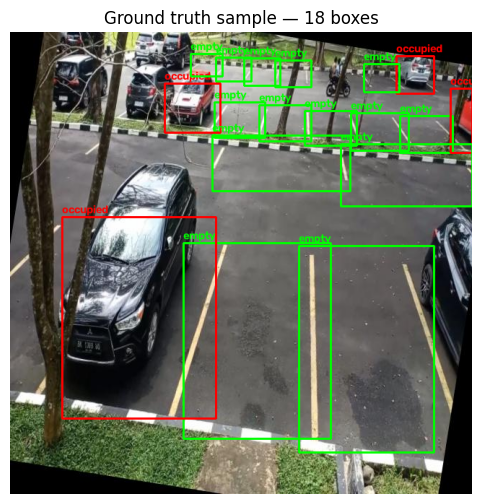

In [5]:
import cv2
import matplotlib.pyplot as plt

def yolo_txt_to_boxes(label_path, img_w, img_h):
    boxes = []
    if not os.path.exists(label_path):
        return boxes
    with open(label_path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) != 5:
                continue
            cls_id, xc, yc, w, h = map(float, parts)
            x1 = int((xc - w/2) * img_w)
            y1 = int((yc - h/2) * img_h)
            x2 = int((xc + w/2) * img_w)
            y2 = int((yc + h/2) * img_h)
            boxes.append((int(cls_id), x1, y1, x2, y2))
    return boxes

sample_img_path = train_images[0]
sample_label_path = sample_img_path.replace("images", "labels").rsplit(".", 1)[0] + ".txt"

img = cv2.imread(sample_img_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
h, w = img.shape[:2]

boxes = yolo_txt_to_boxes(sample_label_path, w, h)
vis = img_rgb.copy()
for cls_id, x1, y1, x2, y2 in boxes:
    color = (0, 255, 0) if "occup" not in str(class_names[cls_id]).lower() else (255, 0, 0)
    cv2.rectangle(vis, (x1, y1), (x2, y2), color, 2)
    cv2.putText(vis, class_names[cls_id], (x1, max(0, y1 - 5)),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)

plt.figure(figsize=(10, 6))
plt.imshow(vis)
plt.title(f"Ground truth sample — {len(boxes)} boxes")
plt.axis("off")
plt.show()


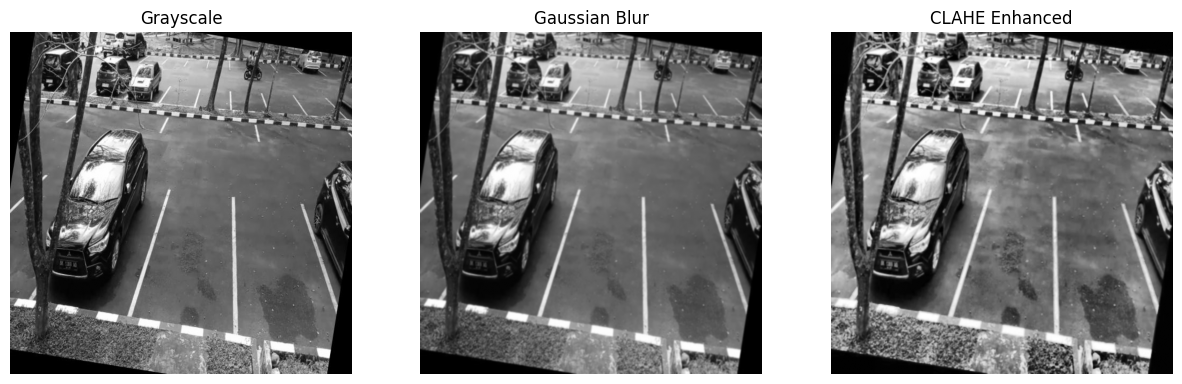

In [6]:
#Preprocessing & Enhancement
def to_grayscale(image):
    return cv2.cvtColor(image, cv2.COLOR_BGR2GRAY) if len(image.shape) == 3 else image

def denoise(gray, kernel_size=(5, 5)):
    return cv2.GaussianBlur(gray, kernel_size, 0)

def enhance_contrast(gray):
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    return clahe.apply(gray)

gray = to_grayscale(img)
blurred = denoise(gray)
enhanced = enhance_contrast(blurred)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, im, title in zip(axes, [gray, blurred, enhanced],
                          ["Grayscale", "Gaussian Blur", "CLAHE Enhanced"]):
    ax.imshow(im, cmap="gray")
    ax.set_title(title)
    ax.axis("off")
plt.show()


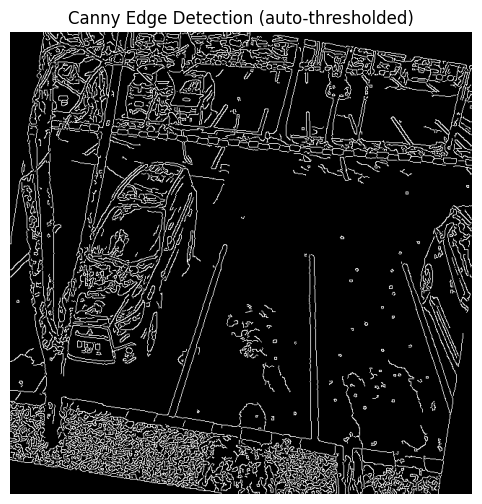

In [7]:
def auto_canny(image, sigma=0.33):
    median = float(np.median(image))
    lower = int(max(0, (1.0 - sigma) * median))
    upper = int(min(255, (1.0 + sigma) * median))
    return cv2.Canny(image, lower, upper)

import numpy as np
edges = auto_canny(enhanced)

plt.figure(figsize=(10, 6))
plt.imshow(edges, cmap="gray")
plt.title("Canny Edge Detection (auto-thresholded)")
plt.axis("off")
plt.show()


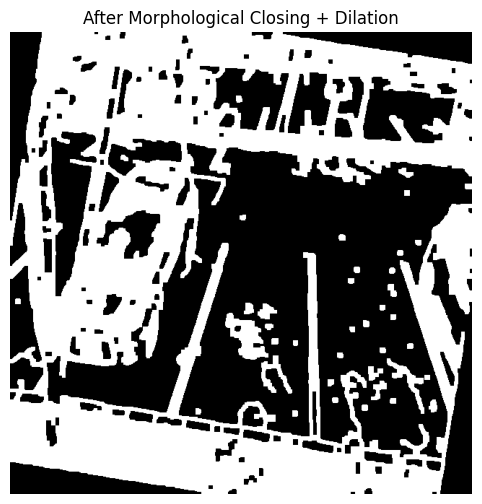

In [8]:
def clean_edges(edges, kernel_size=(5, 5), close_iter=2, dilate_iter=1):
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, kernel_size)
    closed = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, kernel, iterations=close_iter)
    dilated = cv2.dilate(closed, kernel, iterations=dilate_iter)
    return dilated

cleaned = clean_edges(edges)

plt.figure(figsize=(10, 6))
plt.imshow(cleaned, cmap="gray")
plt.title("After Morphological Closing + Dilation")
plt.axis("off")
plt.show()


Auto-detected 0 candidate slot-like contours


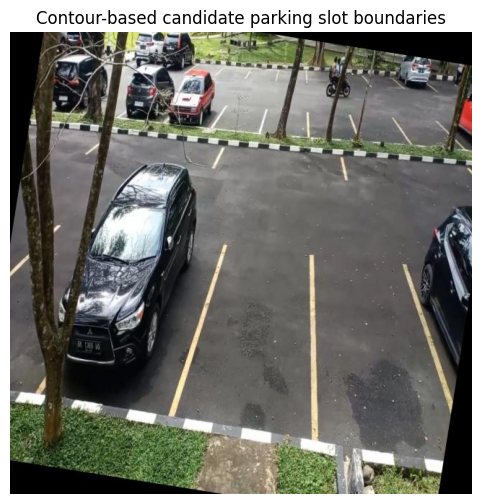

In [9]:
#Contour Detection
def auto_detect_slots(image, cleaned_edges, min_area_ratio=0.002, max_area_ratio=0.5):
    contours, _ = cv2.findContours(cleaned_edges, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)
    img_area = image.shape[0] * image.shape[1]
    slots = []
    for cnt in contours:
        area = cv2.contourArea(cnt)
        if area < img_area * min_area_ratio or area > img_area * max_area_ratio:
            continue
        peri = cv2.arcLength(cnt, True)
        approx = cv2.approxPolyDP(cnt, 0.02 * peri, True)
        if 4 <= len(approx) <= 6:
            slots.append(approx.reshape(-1, 2))
    return slots

auto_slots = auto_detect_slots(img, cleaned)
print(f"Auto-detected {len(auto_slots)} candidate slot-like contours")

vis = img_rgb.copy()
cv2.drawContours(vis, [s.reshape(-1, 1, 2) for s in auto_slots], -1, (255, 165, 0), 2)
plt.figure(figsize=(10, 6))
plt.imshow(vis)
plt.title("Contour-based candidate parking slot boundaries")
plt.axis("off")
plt.show()


In [10]:
from ultralytics import YOLO
model = YOLO("yolov8n.pt")
train_results = model.train(
    data=f"{dataset.location}/data.yaml",
    epochs=50,
    imgsz=640,
    batch=16,
    patience=10,
    project="/content/drive/MyDrive/runs_parking",  # saves straight to Drive
    name="yolov8_parking",
)

Ultralytics 8.4.127 🚀 Python-3.13.15 torch-2.11.0+cpu CPU (AMD EPYC 7B12)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/parking-lot-1/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8_parking, nbs=64, nms=False, opse

In [15]:
!mv /content/drive/MyDrive/runs_parking /content/runs_parking_local_backup

mv: cannot stat '/content/drive/MyDrive/runs_parking': No such file or directory


In [16]:
!rm -rf /content/drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [17]:
!mkdir -p /content/drive/MyDrive/runs_parking
!cp -r /content/runs_parking_local_backup/* /content/drive/MyDrive/runs_parking/

print("Done — your trained weights are now actually in Google Drive.")

Done — your trained weights are now actually in Google Drive.


In [18]:
from google.colab import files
files.download('/content/drive/MyDrive/runs_parking/yolov8_parking/weights/best.pt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [19]:
from ultralytics import YOLO
import cv2, glob, os
import matplotlib.pyplot as plt

model = YOLO('/content/drive/MyDrive/runs_parking/yolov8_parking/weights/best.pt')

test_images = sorted(glob.glob(os.path.join(dataset.location, "valid", "images", "*")))[:10]
os.makedirs('/content/outputs', exist_ok=True)

for img_path in test_images:
    results = model.predict(img_path, conf=0.35)[0]
    annotated = results.plot()  # draws boxes + class + confidence automatically
    out_path = f"/content/outputs/annotated_{os.path.basename(img_path)}"
    cv2.imwrite(out_path, annotated)

print(f"Saved {len(test_images)} annotated images to /content/outputs")


image 1/1 /content/parking-lot-1/valid/images/2022-11-15-14-07-04_mp4-0_jpg.rf.664cc58561ab5c1ad7f5852a300bec6f.jpg: 640x640 18 emptys, 7 occupieds, 189.4ms
Speed: 2.4ms preprocess, 189.4ms inference, 8.3ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/parking-lot-1/valid/images/2022-11-15-14-07-04_mp4-78_jpg.rf.1536fccc48b41df9a706200b74a9c6a0.jpg: 640x640 15 emptys, 7 occupieds, 151.2ms
Speed: 2.0ms preprocess, 151.2ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/parking-lot-1/valid/images/2022-11-15-14-09-20_mp4-19_jpg.rf.1a58b355cf673b116c13a2d472fce9d0.jpg: 640x640 12 emptys, 7 occupieds, 147.1ms
Speed: 1.9ms preprocess, 147.1ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/parking-lot-1/valid/images/2022-11-15-14-11-26_mp4-17_jpg.rf.a7de00e5b117e38ac041d5bc86716b27.jpg: 640x640 3 emptys, 3 occupieds, 157.6ms
Speed: 1.7ms preprocess, 157.6ms inference, 0.8ms postprocess per image 

In [20]:
import pandas as pd

rows = []
for img_path in test_images:
    results = model.predict(img_path, conf=0.35, verbose=False)[0]
    names = results.names
    labels = [names[int(b.cls[0])] for b in results.boxes]
    occ = labels.count("occupied")
    empty = labels.count("empty")
    total = occ + empty
    rows.append({
        "image": os.path.basename(img_path),
        "occupied": occ, "empty": empty, "total": total,
        "occupancy_pct": round(100*occ/total, 1) if total else 0
    })

df = pd.DataFrame(rows)
df.to_csv('/content/outputs/summary.csv', index=False)
df

,image,occupied,empty,total,occupancy_pct
0,2022-11-15-14-07-04_mp4-0_jpg.rf.664cc58561ab5...,7,18,25,28.0
1,2022-11-15-14-07-04_mp4-78_jpg.rf.1536fccc48b4...,7,15,22,31.8
2,2022-11-15-14-09-20_mp4-19_jpg.rf.1a58b355cf67...,7,12,19,36.8
3,2022-11-15-14-11-26_mp4-17_jpg.rf.a7de00e5b117...,3,3,6,50.0
4,2022-11-15-14-11-26_mp4-18_jpg.rf.7a8b7e9f3176...,3,3,6,50.0
5,2022-11-15-14-12-16_mp4-1_jpg.rf.97af2a1b78ac2...,3,3,6,50.0
6,2022-11-15-14-12-16_mp4-2_jpg.rf.94710cd1c1569...,3,2,5,60.0
7,2022-11-15-14-12-16_mp4-3_jpg.rf.3605da578f229...,2,2,4,50.0
8,2022-11-17-13-43-29_mp4-46_jpg.rf.1dbe9abfdcf8...,2,6,8,25.0
9,2022-11-17-13-43-29_mp4-66_jpg.rf.0db72893941a...,2,6,8,25.0


In [21]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

run_dir = "/content/drive/MyDrive/runs_parking/yolov8_parking"

# List everything Ultralytics saved automatically
for f in sorted(os.listdir(run_dir)):
    print(f)

BoxF1_curve.png
BoxPR_curve.png
BoxP_curve.png
BoxR_curve.png
args.yaml
confusion_matrix.png
confusion_matrix_normalized.png
labels.jpg
results.csv
results.png
train_batch0.jpg
train_batch1.jpg
train_batch2.jpg
val_batch0_labels.jpg
val_batch0_pred.jpg
val_batch1_labels.jpg
val_batch1_pred.jpg
val_batch2_labels.jpg
val_batch2_pred.jpg
weights


In [26]:
import cv2
import numpy as np

def annotate_occupancy(img_path, model, conf=0.35):
    img = cv2.imread(img_path)
    results = model.predict(img_path, conf=conf, verbose=False)[0]
    names = results.names

    occupied, vacant = 0, 0
    for box in results.boxes:
        cls_id = int(box.cls[0])
        label = names[cls_id]
        x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())

        if label == "occupied":
            color = (0, 0, 255)   # red (BGR)
            occupied += 1
        else:
            color = (0, 255, 0)   # green (BGR)
            vacant += 1

        cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)

    # stats text at the top, centered
    text = f"Occupied: {occupied} | Vacant: {vacant}"
    (tw, th), _ = cv2.getTextSize(text, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 2)
    x = (img.shape[1] - tw) // 2
    cv2.putText(img, text, (x, 25), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 0), 2, cv2.LINE_AA)

    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

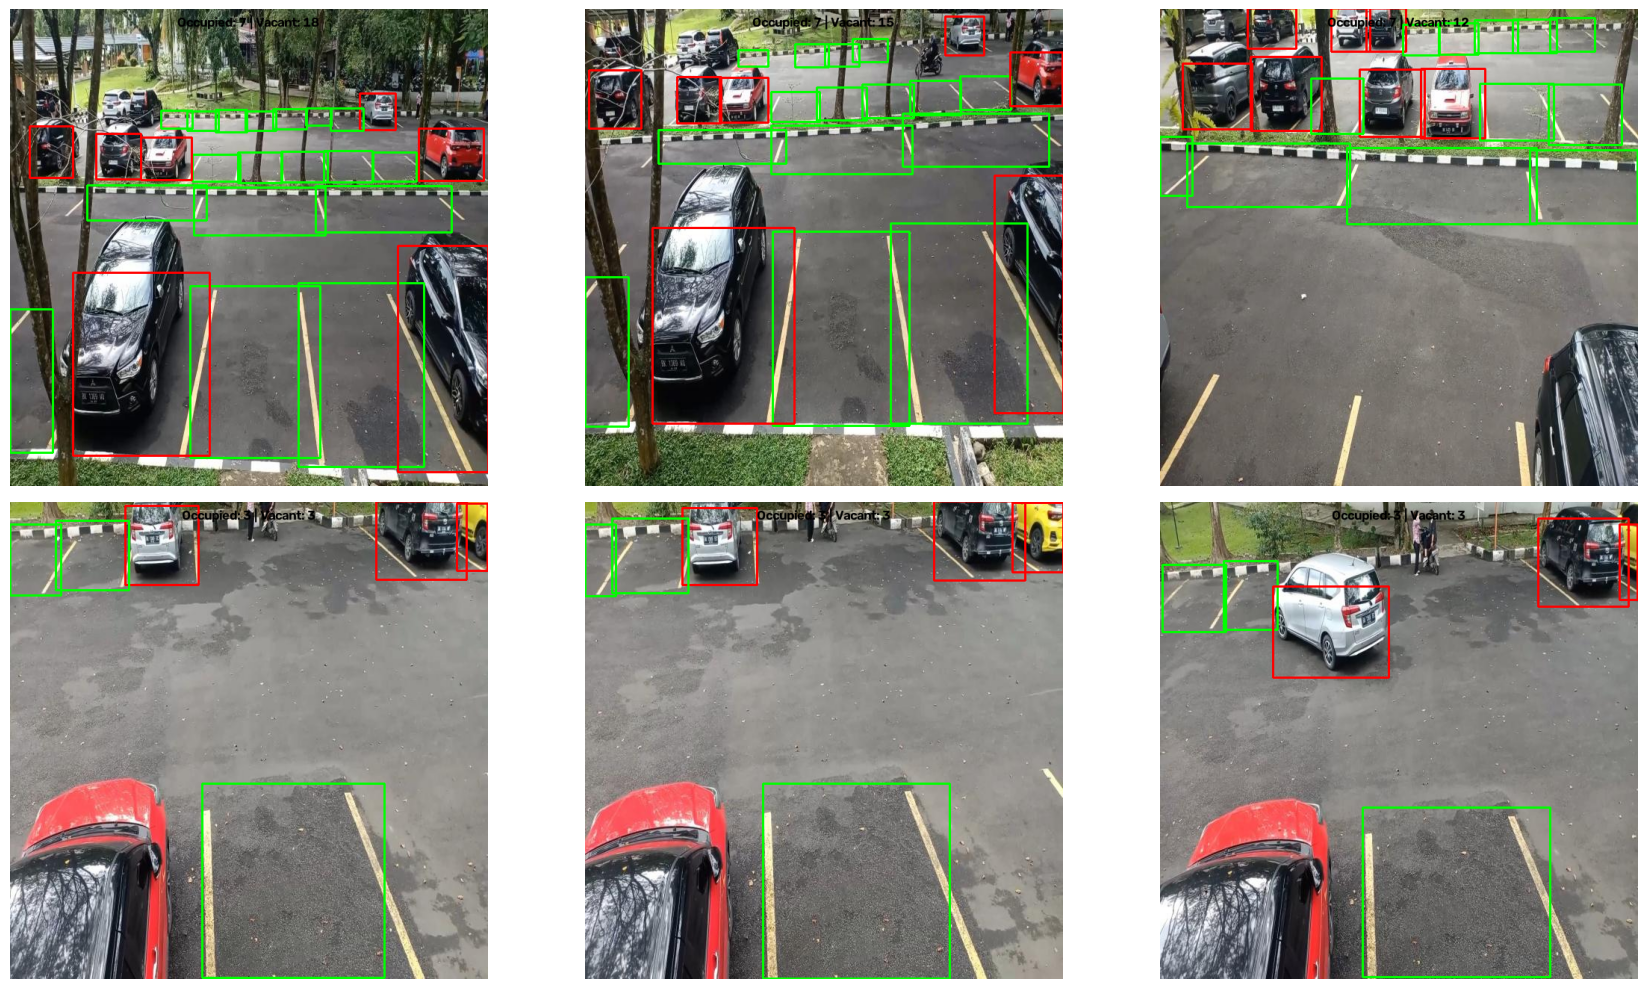

In [25]:
import matplotlib.pyplot as plt
import glob, os

model = YOLO('/content/drive/MyDrive/runs_parking/yolov8_parking/weights/best.pt')

test_images = sorted(glob.glob(os.path.join(dataset.location, "valid", "images", "*")))[:6]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, img_path in zip(axes, test_images):
    annotated = annotate_occupancy(img_path, model)
    ax.imshow(annotated)
    ax.axis("off")

plt.tight_layout()
plt.savefig('/content/outputs/final_results_grid.png', dpi=150, bbox_inches='tight')
plt.show()

In [27]:
!zip -r /content/final_outputs.zip /content/outputs
files.download('/content/final_outputs.zip')

  adding: content/outputs/ (stored 0%)
  adding: content/outputs/final_results_grid.png (deflated 0%)
  adding: content/outputs/annotated_2022-11-15-14-09-20_mp4-19_jpg.rf.1a58b355cf673b116c13a2d472fce9d0.jpg (deflated 4%)
  adding: content/outputs/annotated_2022-11-17-13-43-29_mp4-46_jpg.rf.1dbe9abfdcf8b9a9cdfb875e01afe142.jpg (deflated 4%)
  adding: content/outputs/annotated_2022-11-15-14-11-26_mp4-17_jpg.rf.a7de00e5b117e38ac041d5bc86716b27.jpg (deflated 5%)
  adding: content/outputs/annotated_2022-11-15-14-07-04_mp4-78_jpg.rf.1536fccc48b41df9a706200b74a9c6a0.jpg (deflated 4%)
  adding: content/outputs/summary.csv (deflated 57%)
  adding: content/outputs/annotated_2022-11-15-14-11-26_mp4-18_jpg.rf.7a8b7e9f31767249c7ec18ef604f38c7.jpg (deflated 5%)
  adding: content/outputs/annotated_2022-11-17-13-43-29_mp4-66_jpg.rf.0db72893941a38353b477e99902f4040.jpg (deflated 4%)
  adding: content/outputs/annotated_2022-11-15-14-07-04_mp4-0_jpg.rf.664cc58561ab5c1ad7f5852a300bec6f.jpg (deflated 4%)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>